---
title: Neuro Signal Processing
short_title: Evoked related potentials  
subtitle: Evoked related potentials
description: In this quest we will use real EEG data to compute and visualize ERPs.

---

This chapter will help you develop your numpy array skills in Python. To solve the following exercises you need to have some understanding of:

- arrays and indexing
- loops and if statements
- basic plotting
- basic knowledge of dictionaries

# Event related potentials 

When analyzing electrophysiological activity coming from a certain region of the brain, it is often hard to pinpoint the exact effect of an external stimulus (or event) to that activity. This is so because in signals like EEG there is a constant "background" activity (e.g., other processes happening in the brain, unrelated to the actual effect being investigated), in addition to external noise coming from external interferences. 

One possible way to deal with that, is isolating the brain response to the investigated stimulus by looking for its effect across multiple trials. For example, one can repeatedly record the brain response to the same stimulus across different moments in time (i.e., trials). With the assumption that all the external noise and the unrelated background activity are completely independent from the stimulus, the effect of the processes underlying these two signals can be removed by averaging out the different trials. This uncovers any signal that is event-locked to the stimulus, with constant latency and waveform, which is referred to as an [event related potential](wiki:Event-related_potential) (or event-related field, in the case of a magnetoencephalography signal). 

Given the elapsed time from the stimulus onset $t$, and the trial number $k$, the recorded signal $x$ can be decomposed into:


$x(t,k) = s(t) + n(t,k)$

Where $n(t,k)$ is the noise at a particular time $t$ and trial $k$. Note that the ERP is invariant over different trials (since it is the response evoked directly by the stimulus).

By averaging $N$ trials, we have the following:

$$ \frac{1}{N} \sum_{k=1}^{N} x(t,k) = \frac{1}{N} \sum_{k=1}^{N} s(t) + \frac{1}{N} \sum_{k=1}^{N} n(t,k) =  s(t) + E[n(t,k)]$$

We can see by the formula above that a key assumption to retreive the ERP is that the expected value of the noise is zero (or at least constant), and invariant to trial or time from the stimulus.

Let's practice with a real data example in the next section.

# Dataset

The code below loads a set of variables from an open source EEG dataset in which participants followed an oddball experiment {cite:p}`eeg_dataset`. In this experiment, participants listen to multiple auditory stimuli of 60 ms that could be: standard - most of the stimulus in the session, they don't need to react to it; oddball - a different sound with a lower occurrence in the session, participants need to press a button when they recognize that stimulus; and noise - a stimulus to act as a distractor, different than the standard but with no required action. The EEG was recorded in three sessions of 12 min for each participant. 


The dataset in this quest (which can be downloaded locally here: {download}:`./resources/neuro2.pickle`) corresponds to one session from one participant from {cite}`eeg_dataset`, which can be imported using the `pickle` module (see below). 

The following variables are present in the dataset:

- `signal`: a 2D numpy array with shape (79, 193792). The first dimension represent each recorded channel, while the second dimension represents the timeseries recorded in that chanel.  
- `time`: a numpy array holding the times (in seconds) in which the samples in `signal` were recorded
- `srate`: a float with the sampling rate of the recorded signal (the difference between two consecutive time points in `time` should be $1/srate$)
- `event_time`: a numpy array with the time (in seconds) in which there was an event recorded
- `event_type`: a numpy array with the type of each event in `event_type`. Values range from -1 to 4, depending on the event
- `events`: a dict containing the an explanation (values) for each event type (keys)  in `event_type`. Events type describe the stimulus and the response of the participant on that stimulus (e.g., "oddball with no response") 



:::{code-cell} python
:tags: [skip-execution]
:linenos:
:emphasize-lines: 6
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open('./content/resources/neuro2.pickle', 'rb') as h:
    [signal, time, srate, event_time, event_type, events] = pickle.load(h)
:::



## Exercise 1
Plot the signal of one of the channels over time (use channel 60 to compare to the examples in this quest). Plot also the moments of the stimulus. Investigate what the signal looks like. Are there any concerns or issues that you need to take into consideration?

The image below shows the first 100 seconds of the signal. Your code should have a similar output.

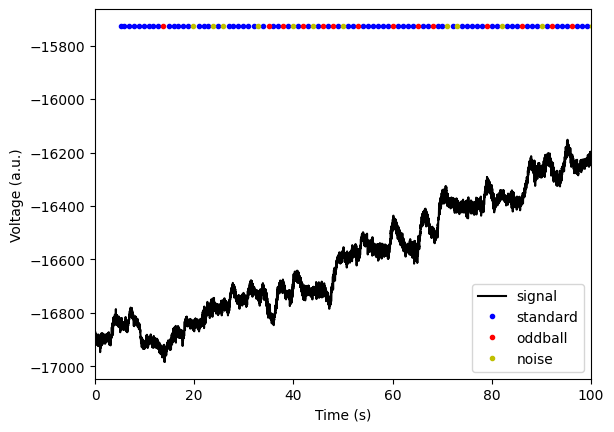

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pickle


with open('./content/resources/neuro2.pickle', 'rb') as h:
    [signal, time, srate, event_time, event_type, events] = pickle.load(h)

ich = 60

plt.plot(time,signal[ich,:],'k')
plt.plot(event_time[event_type==0],event_time[event_type==0]*0+np.max(signal[ich,:]),'.b')
plt.plot(event_time[event_type==1],event_time[event_type==1]*0+np.max(signal[ich,:]),'.r')
plt.plot(event_time[event_type==3],event_time[event_type==3]*0+np.max(signal[ich,:]),'.y')
plt.plot(event_time[event_type==-1],event_time[event_type==-1]*0+np.max(signal[ich,:]),'.r')
plt.xlim(0,100)
plt.legend(["signal",'standard','oddball', 'noise'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (a.u.)')
plt.show()


::::{dropdown} Solution
:::{code-cell} python
:tags: [skip-execution]
import numpy as np
import matplotlib.pyplot as plt
import pickle


with open('./content/resources/neuro2.pickle', 'rb') as h:
    [signal, time, srate, event_time, event_type, events] = pickle.load(h)

ich = 60

plt.plot(time,signal[ich,:],'k')
plt.plot(event_time[event_type==0],event_time[event_type==0]*0+np.max(signal[ich,:]),'.b')
plt.plot(event_time[event_type==1],event_time[event_type==1]*0+np.max(signal[ich,:]),'.r')
plt.plot(event_time[event_type==3],event_time[event_type==3]*0+np.max(signal[ich,:]),'.y')
plt.plot(event_time[event_type==-1],event_time[event_type==-1]*0+np.max(signal[ich,:]),'.r')
plt.xlim(0,100)
plt.legend(["signal",'standard','oddball', 'noise'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (a.u.)')
plt.show()


:::

Notice that the baseline of the signal seems to vary a lot throughout the experimental session. In fact, this variance seems to be higher than any change incurred from trial types. So, in order to see any effect of trial types, we might need to remove the "stable" fluctuations that we see happening - probably due to changes in the signal to noise ration of the signal. Can you think of ways of doing that? Try to think of a method to solve this in the next exercise.
::::

## Exercise 2

Create a numpy 2D array in which every row is a 2-second-window of signal around a standard stimulus (i.e., rows represent the trial, columns represent the time). Build the same matrix for the oddball trials.

Visualize this data by ploting the matrix using the pyplot function imshow(). The raw data should look like the figure below. However, think of a way to solve the problem found in the previous exercise.


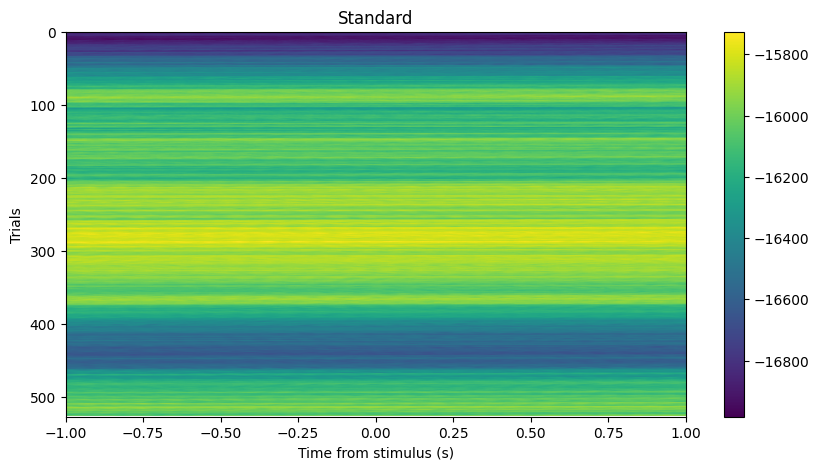

In [88]:

ich = 60

window = np.arange(-1*srate,1*srate, dtype = int)

standard_trials = np.zeros((sum(event_type==0),window.shape[0]))
count = 0
for e in event_time[event_type == 0]:
    try:  
        standard_trials[count,:] = signal[ich, int(e*srate//1) + window]
        # standard_trials[count,:] = standard_trials[count,:]-np.mean(standard_trials[count,:len(window)//2])
        count+=1
    except:
        standard_trials[count,:] = np.nan
        count+=1
        pass


plt.figure(1,figsize=(10,5))
plt.imshow(standard_trials, extent=(-1, 1, count, 0), aspect='auto')
plt.title('Standard')
plt.ylabel("Trials")
plt.xlabel("Time from stimulus (s)")
plt.colorbar()
plt.show()


::::{dropdown} Solution

A simple way of solving the problem of signal stability is to assume that the average of the signal in a window of interest should be constant. Based on that, we can normalize every row (trial) of the matrix by its mean by subtracting it from the signal. Even though there are better ways to do that, this simple solution already changes a lot how the data looks (see below).


:::{code-cell} python

ich = 60

window = np.arange(-1*srate,1*srate, dtype = int)

standard_trials = np.zeros((sum(event_type==0),window.shape[0]))
count = 0
for e in event_time[event_type == 0]:
    try:  
        standard_trials[count,:] = signal[ich, int(e*srate//1) + window]
        standard_trials[count,:] = standard_trials[count,:]-np.mean(standard_trials[count,:])
        count+=1
    except:
        standard_trials[count,:] = np.nan
        count+=1
        pass


plt.figure(1,figsize=(10,10))
plt.subplot(2,1,1)
plt.imshow(standard_trials, extent=(-1, 1, count, 0), aspect='auto')
plt.title('Standard')
plt.ylabel("Trials")
plt.xlabel("Time from stimulus (s)")
plt.colorbar()

oddball_trials = np.zeros((sum(np.abs(event_type)==1),window.shape[0]))
count = 0
for e in event_time[np.abs(event_type) == 1]:
    try:  
        oddball_trials[count,:] = signal[ich, int(e*srate//1) + window]
        oddball_trials[count,:] = oddball_trials[count,:]-np.mean(oddball_trials[count,:])
        count+=1
    except:
        standard_trials[count,:] = np.nan
        count+=1

plt.subplot(2,1,2)
plt.imshow(oddball_trials, extent=(-1, 1, count, 0), aspect='auto')
plt.title('Oddball')
plt.ylabel("Trials")
plt.xlabel("Time from stimulus (s)")
plt.colorbar()
plt.show()

:::

## Normalizing the baseline

Removing the average of the entire window like we did in the code above can be problematic. Can you think why that is the case? Think about the ERP, and what are the differences between the stimulus types. Once you reached your own conclusion, read the section below.

:::{dropdown} Other ways of normalizing

The reason why removing the average of the whole window can be problematic is because we expect to find differences between standard and oddball trials. This means that when we compute the average signal from the whole trial (-1 to 1 second from the stimulus) we might also capture those differences, including them in our normalization. If by any chance, the average signal in one trial type is different than in the other, we are leaking this information into the entire trial. This can be problematic if we are going to use the period before the stimulus as a control (e.g., assuming there is no effect there), because we just artificially introduced the effect! We might also end up diluting the real effect after the stimulus onset.

In addition to the problem above, depending on how much time we look back, we might include changes coming from a previous trial. Because of that, it is important to include a safe inter-trial-iterval when designing experiments.  

To avoid both of these problems, one can restrict the average to be computed only looking at the signal before the stimulus, up to a certain time in which the effect of the previous time is still considered neglectible.   

If we compute the inter-stimulus interval, you can see that for that experiment stimulus happen ~1 second from each other. We can probably assume that 0.5 seconds should be enough to washout the effects of previous trials (ideally, we would also look for that information in the literature). With that in mind, we can compute the normalization by taking into account the 200 ms prior to the stimulus. For example:

`oddball_trials[count,:] = oddball_trials[count,:]-np.mean(oddball_trials[count,len(window)//2-srate//5:len(window)//2])`
:::

There are, of course, other methods to estimate the baseline, with different levels of complexity. One could think of computing a moving average of the signal, fitting a line (sometimes the baseline increase linearly with time), or filtering the out the lower frequencies of the signal. 
::::

## Exercise 3

After implementing the normalization discussed above, compute the ERPs of the standard and oddball trials. Plot the ERPs (average over trials). In addition to the mean ($\mu$), also include the Standard Error of the Mean (SEM) in your plot. This means you will plot three time series: the $\mu$, $\mu + SEM$, and $\mu - SEM$. Use the following formula to calculate the SEM:

$$SEM = \frac{\sigma_x}{\sqrt{N}}$$

Where N is the number of points used to compute the $\sigma$ (i.e., in this case, the total number of trials).

Use the plot below as an example.


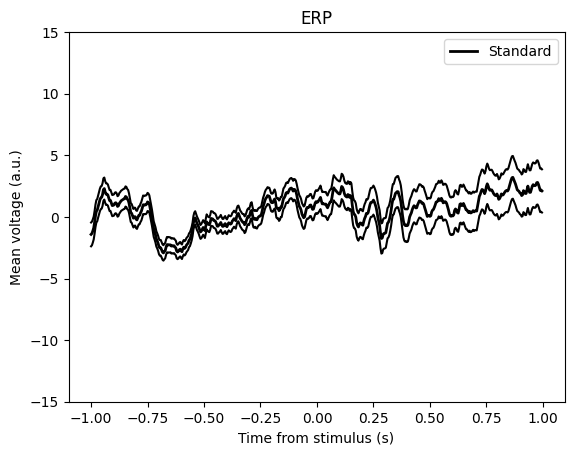

In [ ]:

ich = 60
window = np.arange(-1*srate,1*srate, dtype = int)

standard_trials = np.zeros((sum(event_type==0),window.shape[0]))
count = 0
for e in event_time[event_type == 0]:
    try:  
        standard_trials[count,:] = signal[ich, int(e*srate//1) + window]
        standard_trials[count,:] = standard_trials[count,:]-np.mean(standard_trials[count,:int(len(window)//2)])
        count+=1
    except:
        standard_trials[count,:] = np.nan
        count+=1
        pass



m = np.nanmean(standard_trials, axis=0)
s = np.nanstd(standard_trials, axis=0)/np.sqrt(standard_trials.shape[0])

plt.plot(window/srate,m,'k',linewidth = 2)
plt.plot(window/srate,m+s,'k')
plt.plot(window/srate,m-s,'k')
plt.ylabel("Mean voltage (a.u.)")
plt.xlabel("Time from stimulus (s)")
plt.title('ERP')
plt.legend(['Standard'])
plt.ylim(-15,15)
plt.show()



::::{dropdown} Solution
:::{code-cell} python


m = np.nanmean(standard_trials, axis=0)
s = np.nanstd(standard_trials, axis=0)/np.sqrt(standard_trials.shape[0])


plt.plot(window/srate,m,'k',linewidth = 2, label = 'Standard')
plt.plot(window/srate,m+s,'k')
plt.plot(window/srate,m-s,'k')
plt.ylabel("Mean voltage (a.u.)")
plt.xlabel("Time from stimulus (s)")
plt.title('ERP')
plt.ylim(-15,15)


m = np.nanmean(oddball_trials, axis=0)
s = np.nanstd(oddball_trials, axis=0)/np.sqrt(oddball_trials.shape[0])

plt.plot(window/srate,m,'r',linewidth = 2, label = 'Oddball')
plt.plot(window/srate,m+s,'r')
plt.plot(window/srate,m-s,'r')
plt.ylabel("Mean voltage (a.u.)")
plt.xlabel("Time from stimulus (s)")
plt.title('ERP')
plt.legend()
plt.ylim(-15,15)
plt.show()

:::

# Going further

The big difference that you see around 300 ms in the previous solution is called [P300](wiki:P300_(neuroscience)) (P, from positive, and 300 because of its latency). That is the most obvious one, even though there are also other very well known ERPs associated with the oddball task.

Now that you have computed the ERP of one channel, you can explore a bit more the data. For instance, what is the shape of the ERP when noise is presented? And when there is an oddball stimulus but the participant does not respond? Is the ERP of noise with response similar to the ERP of oddball with response? 

You can also explore other channels, and see how the ERP changes depending on the region of the brain. Or use the filtering function from the previous [section](./neuro-signal-01) to normalize the whole data.
::::

